In [7]:
# =========================================================
# HYBRID ALL DETECTION SYSTEM
# CNN = smear-level ALL classification
# YOLO = lymphoblast detection
# =========================================================

# =========================================================
# 1. MOUNT DRIVE
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# =========================================================
# 2. INSTALL REQUIRED LIBRARIES
# =========================================================
!pip install -q ultralytics

In [9]:
# =========================================================
# 3. IMPORTS
# =========================================================
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

from ultralytics import YOLO
from google.colab import files

In [10]:
# =========================================================
# 4. PATHS - EDIT THESE ONLY
# =========================================================
CNN_DATASET = "/content/drive/MyDrive/Research/cnn_local_data_set"
CNN_MODEL_SAVE = "/content/drive/MyDrive/Research/02_Hybrid/best_efficientnet_all.keras"
YOLO_MODEL_PATH = "/content/drive/MyDrive/Research/01_Hybrid/yolo_model/best.pt"

# Your dataset must be like:
# cnn_dataset/
#    train/
#       ALLNeg/
#       ALLPos/
#    val/
#       ALLNeg/
#       ALLPos/
#    test/
#       ALLNeg/
#       ALLPos/

In [11]:
# =========================================================
# 5. CHECK DATASET COUNTS
# =========================================================
for split in ["train", "val", "test"]:
    print(f"\n{split.upper()}")
    for cls in ["ALLNeg", "ALLPos"]:
        folder = os.path.join(CNN_DATASET, split, cls)
        count = len(os.listdir(folder)) if os.path.exists(folder) else 0
        print(f"{cls}: {count}")


TRAIN
ALLNeg: 22
ALLPos: 32

VAL
ALLNeg: 6
ALLPos: 9

TEST
ALLNeg: 4
ALLPos: 4


In [12]:
# =========================================================
# 6. IMAGE SETTINGS + DATA GENERATORS
# =========================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 8

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.08,
    brightness_range=[0.9, 1.1]
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    os.path.join(CNN_DATASET, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(CNN_DATASET, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(CNN_DATASET, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("\nClass mapping:", train_gen.class_indices)

Found 54 images belonging to 2 classes.
Found 15 images belonging to 2 classes.
Found 8 images belonging to 2 classes.

Class mapping: {'ALLNeg': 0, 'ALLPos': 1}


In [13]:
# =========================================================
# 6. IMAGE SETTINGS + DATA GENERATORS
# =========================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 8

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.08,
    brightness_range=[0.9, 1.1]
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    os.path.join(CNN_DATASET, "train"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    os.path.join(CNN_DATASET, "val"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    os.path.join(CNN_DATASET, "test"),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("\nClass mapping:", train_gen.class_indices)

Found 54 images belonging to 2 classes.
Found 15 images belonging to 2 classes.
Found 8 images belonging to 2 classes.

Class mapping: {'ALLNeg': 0, 'ALLPos': 1}


In [14]:
# =========================================================
# 7. CLASS WEIGHTS
# =========================================================
class_labels = train_gen.classes
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(class_labels),
    y=class_labels
)

class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.2272727272727273), 1: np.float64(0.84375)}


In [15]:
# =========================================================
# 8. BUILD CNN MODEL (TRANSFER LEARNING)
# =========================================================
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_tensor=Input(shape=(224, 224, 3))
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,131,620 (15.76 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
# =========================================================
# 9. CALLBACKS
# =========================================================
os.makedirs(os.path.dirname(CNN_MODEL_SAVE), exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        CNN_MODEL_SAVE,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

In [17]:
# =========================================================
# 10. TRAIN STAGE 1
# =========================================================
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4322 - loss: 0.7488
Epoch 1: val_accuracy improved from -inf to 0.40000, saving model to /content/drive/MyDrive/Research/02_Hybrid/best_efficientnet_all.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - accuracy: 0.4383 - loss: 0.7479 - val_accuracy: 0.4000 - val_loss: 0.6946 - learning_rate: 1.0000e-04
Epoch 2/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.3898 - loss: 0.7720
Epoch 2: val_accuracy did not improve from 0.40000
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 804ms/step - accuracy: 0.3989 - loss: 0.7710 - val_accuracy: 0.4000 - val_loss: 0.6770 - learning_rate: 1.0000e-04
Epoch 3/25
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.3946 - loss: 0.7694
Epoch 3: val_accuracy improved from 0.40000 to 0.53333, saving model to /content/drive/MyDrive/Research/02_Hybrid/best_efficientnet_all.keras
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3986 - loss: 0.7657 - val_accuracy: 0.5333 - val_loss: 0.6669 - learning_rate: 1.0000

In [18]:
# =========================================================
# 11. FINE-TUNE STAGE 2
# =========================================================
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 757ms/step - accuracy: 0.7428 - loss: 0.6122
Epoch 1: val_accuracy did not improve from 0.86667
7/7 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.7379 - loss: 0.6139 - val_accuracy: 0.8000 - val_loss: 0.5119 - learning_rate: 1.0000e-05
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 745ms/step - accuracy: 0.6956 - loss: 0.6952
Epoch 2: val_accuracy did not improve from 0.86667
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 946ms/step - accuracy: 0.6966 - loss: 0.6912 - val_accuracy: 0.7333 - val_loss: 0.5132 - learning_rate: 1.0000e-05
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6772 - loss: 0.6257
Epoch 3: val_accuracy did not improve from 0.86667
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6782 - loss: 0.6262 - val_accuracy: 0.8000 - val_loss: 0.5150 - learning_rate: 1.0000e-05
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.7342 - loss: 0.5762
Epoch 4: val_accuracy did not improve from 0.86667

Epoch 4: ReduceLROnPlateau reducing le

In [19]:
# =========================================================
# 12. LOAD BEST CNN MODEL
# =========================================================
cnn_model = load_model(CNN_MODEL_SAVE)
print("Best CNN model loaded.")

Best CNN model loaded.


In [20]:
# =========================================================
# 13. TEST CNN MODEL
# =========================================================
test_loss, test_acc = cnn_model.evaluate(test_gen, verbose=1)
print("\n===== TEST RESULTS =====")
print("Test Loss     :", test_loss)
print("Test Accuracy :", test_acc)

pred_probs = cnn_model.predict(test_gen, verbose=1)
preds = (pred_probs > 0.5).astype(int).flatten()

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(
    test_gen.classes,
    preds,
    target_names=list(train_gen.class_indices.keys())
))

print("\nConfusion Matrix:")
print(confusion_matrix(test_gen.classes, preds))

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.7500 - loss: 0.4972

===== TEST RESULTS =====
Test Loss     : 0.4971644878387451
Test Accuracy : 0.75
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

      ALLNeg       1.00      0.50      0.67         4
      ALLPos       0.67      1.00      0.80         4

    accuracy                           0.75         8
   macro avg       0.83      0.75      0.73         8
weighted avg       0.83      0.75      0.73         8


Confusion Matrix:
[[2 2]
 [0 4]]


In [21]:
# =========================================================
# 14. LOAD YOLO MODEL
# =========================================================
yolo_model = YOLO(YOLO_MODEL_PATH)
print("YOLO model loaded.")

YOLO model loaded.


In [38]:
# =========================================================
# HYBRID PREDICTION FUNCTION
# Final output = only final decision
# =========================================================
def hybrid_predict(image_path, cnn_threshold=0.7, yolo_conf=0.35):
    # -------------------------
    # CNN prediction
    # -------------------------
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Could not read image.")
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_array = np.expand_dims(img_resized.astype(np.float32), axis=0)
    img_array = preprocess_input(img_array)

    cnn_prob = float(cnn_model.predict(img_array, verbose=0)[0][0])

    # -------------------------
    # YOLO prediction
    # -------------------------
    results = yolo_model.predict(image_path, conf=yolo_conf, verbose=False)
    result = results[0]
    boxes = result.boxes

    blast_count = 0
    if boxes is not None and len(boxes) > 0:
        blast_count = len(boxes)

    # -------------------------
    # Final hybrid decision
    # -------------------------
    if blast_count >= 1:
        final_result = "ALL Positive"
    else:
        final_result = "ALL Negative"

    # -------------------------
    # Show final result only
    # -------------------------
    print("\n===== FINAL RESULT =====")
    print(final_result)

    plotted = result.plot()
    plt.figure(figsize=(8, 8))
    plt.imshow(cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    return final_result

Saving 122f_jpg.rf.6a0afa82997cbbf444effbf97c34fc35.jpg to 122f_jpg.rf.6a0afa82997cbbf444effbf97c34fc35 (1).jpg

===== FINAL RESULT =====
ALL Positive


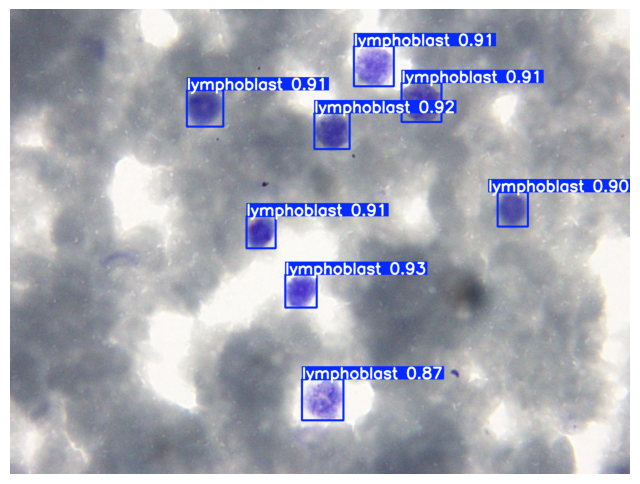

In [45]:
# =========================================================
# 16. UPLOAD IMAGE AND TEST HYBRID MODEL
# =========================================================
uploaded = files.upload()

for img_name in uploaded.keys():
    hybrid_predict(img_name)